In [27]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

conn = sqlite3.connect("../data.db")

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from src.config import TARGETS

tweets = pd.read_sql_query("SELECT * FROM tweets", conn, parse_dates=["created_at"])
users = pd.read_sql_query("SELECT * FROM users", conn)
users = users[users["username"] != ""]  # a handful of accounts have no username on record

_target_casing = {t.lower(): t for t in TARGETS}
users["username"] = users["username"].apply(lambda u: _target_casing.get(u.lower(), u))

tweets = tweets.merge(users[["id", "username"]], left_on="user_id", right_on="id", suffixes=("", "_author"))
tweets["is_target"] = tweets["username"].isin(TARGETS)
tweets["is_reply"] = tweets["parent_tweet_id"].notna()

## 1. Coverage — profile `tweets_count` vs tweets actually collected (see `tools/coverage.py`)

In [28]:
coverage = tweets.groupby("user_id").agg(own=("is_reply", lambda s: (~s).sum()), total=("is_reply", "size"))
coverage = users.set_index("id")[["username", "tweets_count"]].join(coverage)
coverage = coverage.set_index("username").reindex(TARGETS)
coverage[["tweets_count", "own", "total"]] = coverage[["tweets_count", "own", "total"]].fillna(0).astype(int)
coverage["pct"] = coverage["own"] / coverage["tweets_count"].replace(0, pd.NA) * 100
coverage.sort_values("pct", ascending=False)

,tweets_count,own,total,pct
username,,,,
Pontifex_ar,736,725,726,98.505435
osekguub6096Gwf,15,14,15,93.333333
MmedHamdaoui,1110,996,1007,89.729730
ar_khamenei,4677,4046,4054,86.508446
itamarbengvir,10264,8774,8774,85.483242
SecRubio,1337,1101,1101,82.348542
khamenei_ir,13529,10946,10946,80.907680
DiyanetDijital,4012,3160,3163,78.763709
fm6oaorg,2411,1842,1842,76.399834


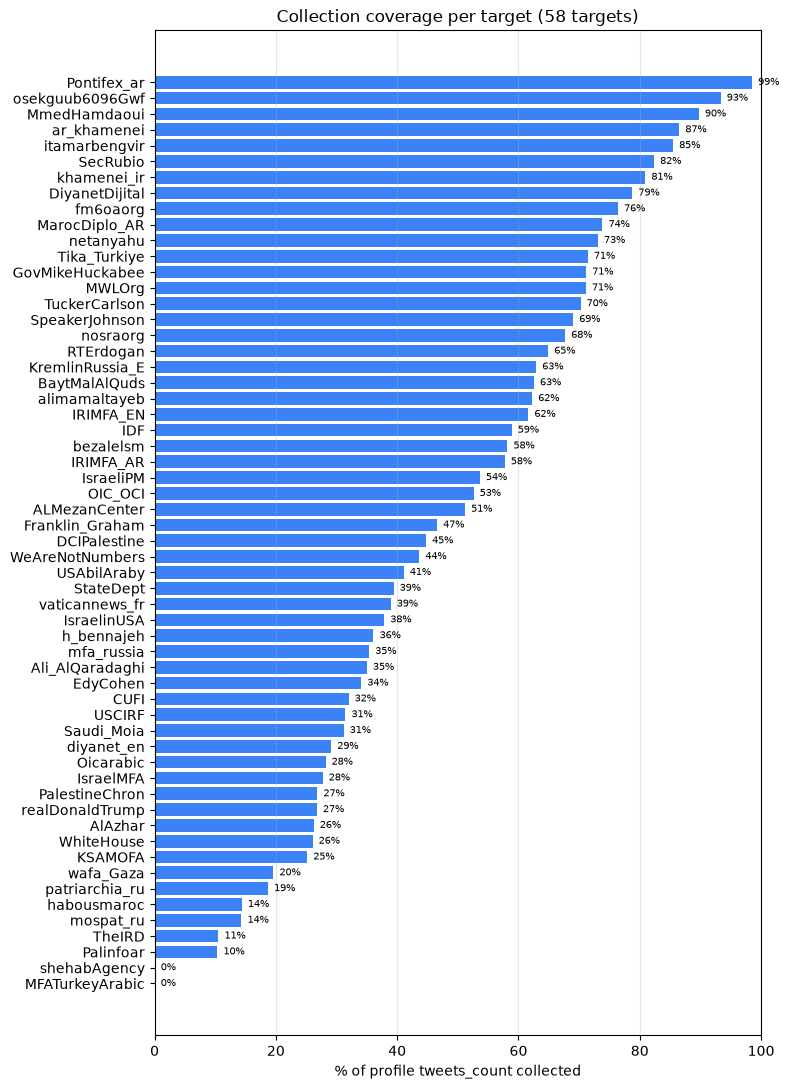

In [29]:
cov_sorted = coverage["pct"].fillna(0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(cov_sorted.index, cov_sorted.values, color="#3B82F6")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of profile tweets_count collected")
ax.set_title(f"Collection coverage per target ({len(TARGETS)} targets)")
ax.grid(axis="x", alpha=0.3)
for y, v in enumerate(cov_sorted.values):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=7)
plt.tight_layout()

In [30]:
root_tweets = tweets[~tweets["is_reply"]]
parent_author = tweets.set_index("id")["username"]
replies_only = tweets[tweets["is_reply"]].copy()
replies_only["parent_author"] = replies_only["parent_tweet_id"].map(parent_author)

## 18. Level-1 vs level-2 reply coverage per target tweet (reply-graph depth, see `src/extraction/delta.py`)

In [31]:
parent_of = tweets.set_index("id")["parent_tweet_id"]
root_of_target = root_tweets[root_tweets["is_target"]].set_index("id")

# level-1: replies whose immediate parent is a target's root tweet
l1 = replies_only[replies_only["parent_tweet_id"].isin(root_of_target.index)].copy()
l1["root_tweet_id"] = l1["parent_tweet_id"]

# level-2: replies whose immediate parent is itself a level-1 reply;
# walk one extra parent_tweet_id hop to find the original target root tweet
l1_ids = set(l1["id"])
l2 = replies_only[replies_only["parent_tweet_id"].isin(l1_ids)].copy()
l2["root_tweet_id"] = l2["parent_tweet_id"].map(parent_of)

l1_counts = l1.groupby("root_tweet_id").size().rename("l1_replies")
l2_counts = l2.groupby("root_tweet_id").size().rename("l2_replies")

reply_graph = root_of_target[["username", "text", "reply_count", "like_count"]].join(l1_counts).join(l2_counts).fillna(0)
reply_graph[["l1_replies", "l2_replies"]] = reply_graph[["l1_replies", "l2_replies"]].astype(int)

In [32]:
# per-target rollup: total + per-tweet level-1 / level-2 replies collected so far
per_target_graph = reply_graph.groupby("username")[["l1_replies", "l2_replies"]].sum().reindex(TARGETS).fillna(0).astype(int)
per_target_graph["tweets"] = reply_graph.groupby("username").size().reindex(TARGETS).fillna(0).astype(int)
tweets_denom = per_target_graph["tweets"].replace(0, pd.NA).astype("float64")
per_target_graph["l1_replies_per_tweet"] = (per_target_graph["l1_replies"] / tweets_denom).round(2)
per_target_graph["l2_replies_per_tweet"] = (per_target_graph["l2_replies"] / tweets_denom).round(2)
per_target_graph = per_target_graph[["tweets", "l1_replies", "l1_replies_per_tweet", "l2_replies", "l2_replies_per_tweet"]]
per_target_graph.sort_values("l2_replies", ascending=False)

TypeError: float() argument must be a string or a real number, not 'NAType'

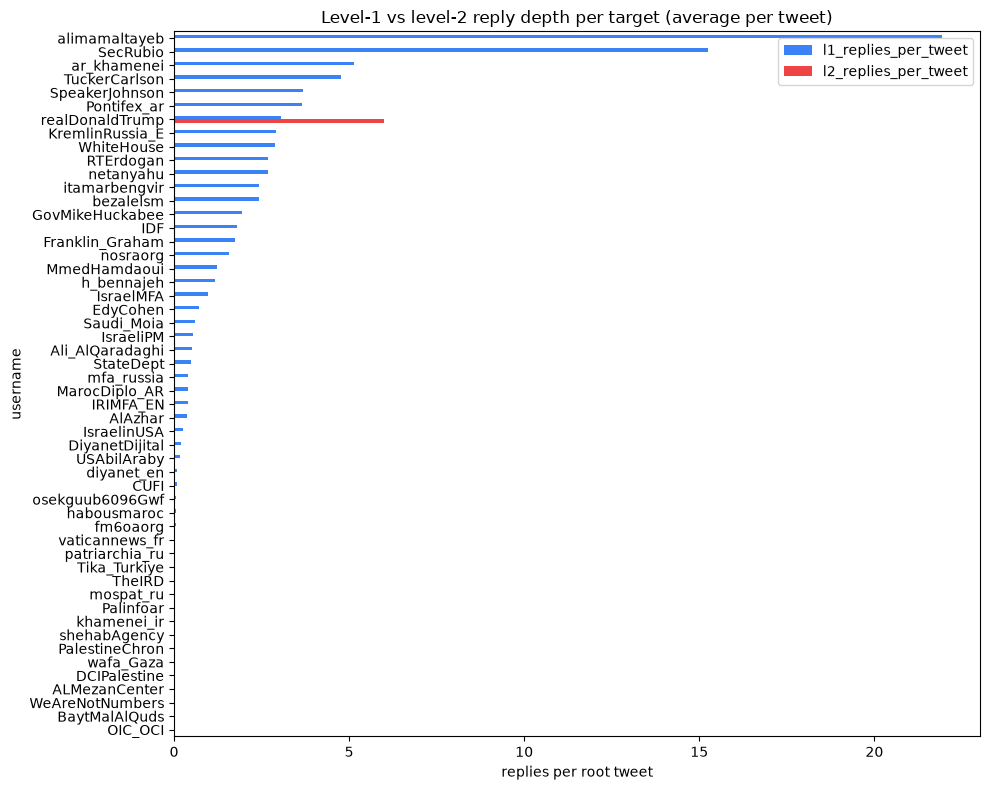

In [ ]:
plot_data = per_target_graph[["l1_replies_per_tweet", "l2_replies_per_tweet"]].sort_values("l1_replies_per_tweet", ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
plot_data.plot.barh(ax=ax, color=["#3B82F6", "#EF4444"])
ax.invert_yaxis()
ax.set_xlabel("replies per root tweet")
ax.set_title("Level-1 vs level-2 reply depth per target (average per tweet)")
plt.tight_layout()

## `media_type` backfill coverage — rows not yet classified (see `src/extraction/epsilon.py`)

`media_type` is NULL until backfilled, so `isna()` is the pending queue.

In [ ]:
done_mask = tweets["media_type"].notna()
print(f"{done_mask.sum():,} / {len(tweets):,} tweets backfilled ({done_mask.mean() * 100:.1f}%), "
      f"{(~done_mask).sum():,} pending")
tweets.loc[done_mask, "media_type"].value_counts().to_frame("tweets")

62,452 / 1,016,940 tweets backfilled (6.1%), 954,488 pending


,tweets
media_type,
text,34169
"image,text",23319
"text,video",4288
image,536
"image,text,video",113
"gif,text",14
video,8
unknown,5


In [ ]:
mt_coverage = tweets.groupby("user_id")["media_type"].agg(done="count", total="size")
mt_coverage = users.set_index("id")[["username"]].join(mt_coverage).set_index("username").reindex(TARGETS)
mt_coverage[["done", "total"]] = mt_coverage[["done", "total"]].fillna(0).astype(int)
mt_coverage["pending"] = mt_coverage["total"] - mt_coverage["done"]
mt_coverage["pct_done"] = (mt_coverage["done"] / mt_coverage["total"].replace(0, pd.NA) * 100).round(1)
mt_coverage.sort_values("pct_done")

,done,total,pending,pct_done
username,,,,
ar_khamenei,0,4054,4054,0.0
IsraelMFA,0,12225,12225,0.0
IsraelinUSA,0,11876,11876,0.0
EdyCohen,0,30327,30327,0.0
IsraeliPM,0,13951,13951,0.0
IDF,0,15222,15222,0.0
MmedHamdaoui,0,1007,1007,0.0
itamarbengvir,0,8774,8774,0.0
bezalelsm,0,10281,10281,0.0


## Category-combination breakdown per target

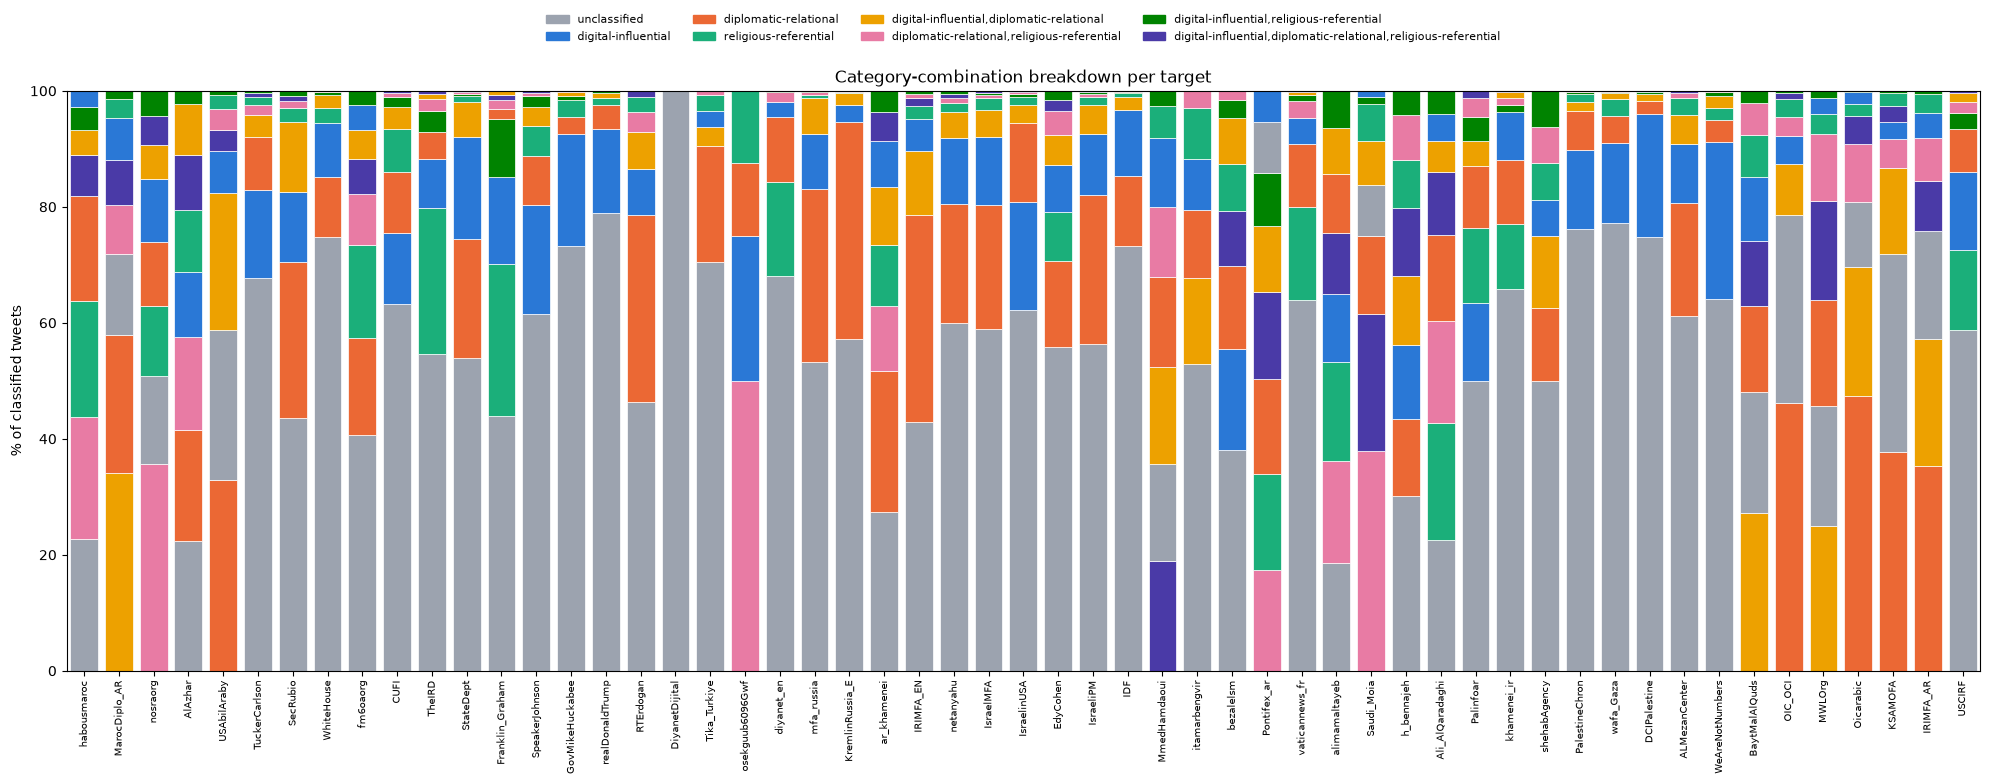

In [35]:
COMBO_COLORS = {
    "unclassified": "#9CA3AF",
    "digital-influential": "#2a78d6",
    "diplomatic-relational": "#eb6834",
    "religious-referential": "#1baf7a",
    "digital-influential,diplomatic-relational": "#eda100",
    "diplomatic-relational,religious-referential": "#e87ba4",
    "digital-influential,religious-referential": "#008300",
    "digital-influential,diplomatic-relational,religious-referential": "#4a3aa7",
}

classified = tweets[tweets["is_target"] & tweets["category"].notna()].copy()
classified["combo"] = classified["category"].apply(
    lambda c: c if c == "unclassified" else ",".join(sorted(x.strip() for x in c.split(",")))
)

pivot = classified.groupby(["username", "combo"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=list(COMBO_COLORS), fill_value=0).reindex(TARGETS).fillna(0)
pivot = pivot[pivot.sum(axis=1) > 0]  # drop targets with no classified tweets
pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(20, 8))
for x, target in enumerate(pct.index):
    bottom = 0.0
    for combo, v in pct.loc[target].sort_values(ascending=False).items():  # largest segment as the base, per target
        ax.bar(x, v, bottom=bottom, color=COMBO_COLORS[combo], edgecolor="white", linewidth=0.5)
        bottom += v
ax.set_xlim(-0.5, len(pct.index) - 0.5)
ax.set_ylim(0, 100)
ax.set_xticks(range(len(pct.index)))
ax.set_xticklabels(pct.index)
ax.set_ylabel("% of classified tweets")
ax.set_title("Category-combination breakdown per target")
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=7)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in COMBO_COLORS.values()]
ax.legend(legend_handles, COMBO_COLORS.keys(), bbox_to_anchor=(0.5, 1.15), loc="upper center", ncol=4, fontsize=8, frameon=False)
plt.tight_layout()